Data source : https://www.kaggle.com/c/home-credit-default-risk/data

But notebook : Feature Engineering / Reduction

- utiliser les donnes agrégées précédemment
- réduire le dataframe (optimisation de futurs temps de calcul / temps de modélisation) tout en ayant le moins de données manquantes dans les features restantes
   - verification des types et choix de types plus avantageux en poids si possible
   - entrainement sur différents modèles et extraction des features notables via SHAPE ou autre (knn most important features)
   - éviter de "créer" des informations ex-nihilo avec de l'inputing : favoriser la sélection / suppression en préservant au mieux l'intégrité des données

# Imports

## libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import inspect

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

In [4]:
import gc
import time
from contextlib import contextmanager
import re

In [5]:
# https://numpy.org/doc/stable/release/2.0.0-notes.html#representation-of-numpy-scalars-changed
np.set_printoptions(legacy='1.21')

In [6]:
import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.sklearn

from mlflow import MlflowClient
from mlflow.models.signature import infer_signature
from pprint import pprint

In [7]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn import model_selection
import xgboost as xgb


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, fbeta_score, make_scorer, fbeta_score, precision_recall_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from imblearn.over_sampling import SMOTE
import shap

In [8]:
import pickle
import shutil

## data

In [9]:
csv_path_output = '../data/output/'
#X_train_filename = 'train_df_cleaned_smote.parquet.gzip'
X_train_filename = 'train_df_cleaned.parquet.gzip'
X_test_filename = 'test_df_cleaned.parquet.gzip'

X_train = pd.read_parquet(csv_path_output + X_train_filename)
X_test_kag = pd.read_parquet(csv_path_output + X_test_filename)

In [10]:
X_train.columns

Index(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'PAYMENT_RATE', 'INSTAL_DPD_MEAN',
       'INSTAL_AMT_PAYMENT_SUM', 'AMT_ANNUITY', 'DAYS_BIRTH', 'CODE_GENDER',
       'ANNUITY_INCOME_PERC', 'APPROVED_AMT_DOWN_PAYMENT_MAX',
       'DAYS_EMPLOYED_PERC', 'BURO_DAYS_CREDIT_MEAN', 'PREV_CNT_PAYMENT_MEAN',
       'AMT_GOODS_PRICE', 'BURO_AMT_CREDIT_SUM_DEBT_MEAN',
       'ACTIVE_DAYS_CREDIT_MAX', 'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN',
       'PREV_APP_CREDIT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_MEAN',
       'NAME_EDUCATION_TYPE_Highereducation', 'DAYS_ID_PUBLISH',
       'APPROVED_CNT_PAYMENT_MEAN', 'BURO_DAYS_CREDIT_MAX',
       'INSTAL_AMT_PAYMENT_MIN', 'INSTAL_DAYS_ENTRY_PAYMENT_SUM',
       'POS_MONTHS_BALANCE_SIZE', 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
       'DAYS_REGISTRATION', 'PREV_APP_CREDIT_PERC_MIN',
       'APPROVED_DAYS_DECISION_MIN', 'INSTAL_AMT_PAYMENT_MEAN',
       'INSTAL_DBD_SUM', 'INSTAL_AMT_INSTALMENT_MAX', 'INCOME_CREDIT_PERC',
       'INSTAL_DAYS_ENTRY_PAYMENT_MEAN', 'INSTAL_PAYM

In [11]:
X_train.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET,SK_ID_CURR
0,0.262949,0.139376,0.060749,0.000000,219625.68750,24700.5,-9461,0,0.121978,0.0,...,1.000000,-606.0,11559.247070,388.0,53093.746094,0.498036,-315.421051,0.000000,1.0,100002
5,0.354225,0.621226,0.056101,37.628571,957617.62500,27517.5,-16941,0,0.277955,12145.5,...,0.896459,-2536.0,27360.501953,403.0,432218.281250,0.201837,-1237.800049,342.461578,0.0,100008
6,0.724000,0.492060,0.026463,0.137255,487995.12500,41301.0,-13778,1,0.241526,22032.0,...,1.000000,-1562.0,9568.532227,445.0,17341.605469,0.109564,-864.411743,0.000000,0.0,100009
7,0.714279,0.540654,0.027500,0.000000,274492.09375,42075.0,-18850,0,0.116875,0.0,...,0.947859,-1070.0,27449.207031,119.0,27463.410156,0.235294,-915.900024,0.000000,0.0,100010
10,0.651862,0.363945,0.032455,1.052632,166880.75000,21177.0,-10197,1,0.188240,0.0,...,0.904484,-844.0,8783.197266,176.0,14045.625000,0.172414,-584.473694,3043.009033,0.0,100014


In [12]:
X_train.shape

(143691, 38)

In [13]:
X_test_kag.columns

Index(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'PAYMENT_RATE',
       'INSTAL_DPD_MEAN', 'INSTAL_AMT_PAYMENT_SUM', 'AMT_ANNUITY',
       'DAYS_BIRTH', 'CODE_GENDER', 'ANNUITY_INCOME_PERC',
       'APPROVED_AMT_DOWN_PAYMENT_MAX', 'DAYS_EMPLOYED_PERC',
       'BURO_DAYS_CREDIT_MEAN', 'PREV_CNT_PAYMENT_MEAN', 'AMT_GOODS_PRICE',
       'BURO_AMT_CREDIT_SUM_DEBT_MEAN', 'ACTIVE_DAYS_CREDIT_MAX',
       'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN', 'PREV_APP_CREDIT_PERC_MEAN',
       'INSTAL_PAYMENT_PERC_MEAN', 'NAME_EDUCATION_TYPE_Highereducation',
       'DAYS_ID_PUBLISH', 'APPROVED_CNT_PAYMENT_MEAN', 'BURO_DAYS_CREDIT_MAX',
       'INSTAL_AMT_PAYMENT_MIN', 'INSTAL_DAYS_ENTRY_PAYMENT_SUM',
       'POS_MONTHS_BALANCE_SIZE', 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
       'DAYS_REGISTRATION', 'PREV_APP_CREDIT_PERC_MIN',
       'APPROVED_DAYS_DECISION_MIN', 'INSTAL_AMT_PAYMENT_MEAN',
       'INSTAL_DBD_SUM', 'INSTAL_AMT_INSTALMENT_MAX', 'INCOME_CREDIT_PERC',
       'INSTAL_DAYS_ENTRY_PAYMENT_MEA

In [14]:
X_test_kag.head()

,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_1,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,SK_ID_CURR
307507,0.789654,0.159520,0.752614,0.036147,1.571429,41195.925781,20560.5,-19241,1,0.152300,...,-5170.0,1.044079,-1740.0,5885.132324,62.0,17397.900391,0.237342,-2195.000000,0.00000,100001
307508,0.291656,0.432962,0.564990,0.077973,0.111111,56161.843750,17370.0,-18064,0,0.175455,...,-9118.0,1.111173,-757.0,6240.205078,213.0,17656.244141,0.444409,-609.555542,0.00000,100005
307510,0.509677,0.612704,0.525734,0.031123,0.265487,492310.656250,49018.5,-13976,1,0.155614,...,-2000.0,0.000000,-1805.0,4356.731445,369.0,38988.539062,0.200000,-858.548645,622.55072,100028
307514,0.613033,0.312365,0.565290,0.079000,0.000000,90726.750000,14220.0,-9516,0,0.085405,...,-5063.0,1.428571,-1182.0,18145.349609,68.0,18150.705078,0.925000,-1104.599976,0.00000,100065
307515,0.808788,0.522697,0.718507,0.079358,0.000000,462151.968750,28957.5,-12744,1,0.091929,...,-1686.0,0.825628,-829.0,10270.043945,427.0,21199.544922,0.863260,-392.688904,0.00000,100066


In [15]:
X_test_kag.shape

(15588, 38)

In [16]:
X_train.drop(columns=['SK_ID_CURR'], inplace=True)
#X_test_kag.drop(columns=['SK_ID_CURR'], inplace=True)

# Explo

## Valeurs manquantes

In [17]:
# https://medium.com/@kavyasree42/how-to-handle-missing-data-in-python-simple-to-advanced-techniques-machine-learning-brain-ffae3c1a694f

In [18]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))
    
# Function to calculate missing values by column
def missing_values_table(df):
    # Taux de valeurs manquantes :
    print("Taux de valeurs manquantes dans le df avant imputation :" , round(df.isna().mean().mean(),4))
    # Total missing values
    mis_val = df.isnull().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
           " columns that have missing values.")
    
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [19]:
#  Statistiques sur les valeurs manquantes :
missing_values = missing_values_table(X_train)
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)

print(X_train.shape, X_test_kag.shape)
X_train["TARGET"].value_counts()/X_train.shape[0]

# Taux de valeurs manquantes :
print("Taux de valeurs manquantes dans jeu de train avant imputation :" , round(X_train.isna().mean().mean(),4))
print("Taux de valeurs manquantes dans jeu de test avant imputation :" , round(X_test_kag.isna().mean().mean(),4))

Taux de valeurs manquantes dans le df avant imputation : 0.0
Your selected dataframe has 37 columns.
There are 0 columns that have missing values.
(143691, 37) (15588, 38)
Taux de valeurs manquantes dans jeu de train avant imputation : 0.0
Taux de valeurs manquantes dans jeu de test avant imputation : 0.0


## Typage

In [20]:
X_train.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,TARGET
0,0.262949,0.139376,0.060749,0.000000,219625.68750,24700.5,-9461,0,0.121978,0.0,...,-3648.0,1.000000,-606.0,11559.247070,388.0,53093.746094,0.498036,-315.421051,0.000000,1.0
5,0.354225,0.621226,0.056101,37.628571,957617.62500,27517.5,-16941,0,0.277955,12145.5,...,-4970.0,0.896459,-2536.0,27360.501953,403.0,432218.281250,0.201837,-1237.800049,342.461578,0.0
6,0.724000,0.492060,0.026463,0.137255,487995.12500,41301.0,-13778,1,0.241526,22032.0,...,-1213.0,1.000000,-1562.0,9568.532227,445.0,17341.605469,0.109564,-864.411743,0.000000,0.0
7,0.714279,0.540654,0.027500,0.000000,274492.09375,42075.0,-18850,0,0.116875,0.0,...,-4597.0,0.947859,-1070.0,27449.207031,119.0,27463.410156,0.235294,-915.900024,0.000000,0.0
10,0.651862,0.363945,0.032455,1.052632,166880.75000,21177.0,-10197,1,0.188240,0.0,...,-4427.0,0.904484,-844.0,8783.197266,176.0,14045.625000,0.172414,-584.473694,3043.009033,0.0


In [21]:
X_train.dtypes

EXT_SOURCE_2                              float32
EXT_SOURCE_3                              float32
PAYMENT_RATE                              float32
INSTAL_DPD_MEAN                           float32
INSTAL_AMT_PAYMENT_SUM                    float32
AMT_ANNUITY                               float32
DAYS_BIRTH                                  int16
CODE_GENDER                                  int8
ANNUITY_INCOME_PERC                       float32
APPROVED_AMT_DOWN_PAYMENT_MAX             float32
DAYS_EMPLOYED_PERC                        float32
BURO_DAYS_CREDIT_MEAN                     float32
PREV_CNT_PAYMENT_MEAN                     float32
AMT_GOODS_PRICE                           float32
BURO_AMT_CREDIT_SUM_DEBT_MEAN             float32
ACTIVE_DAYS_CREDIT_MAX                    float32
ACTIVE_DAYS_CREDIT_ENDDATE_MEAN           float32
PREV_APP_CREDIT_PERC_MEAN                 float32
INSTAL_PAYMENT_PERC_MEAN                  float32
NAME_EDUCATION_TYPE_Highereducation          int8


In [22]:
X_train['TARGET'].value_counts(dropna=False)

TARGET
0.0    131252
1.0     12439
Name: count, dtype: int64

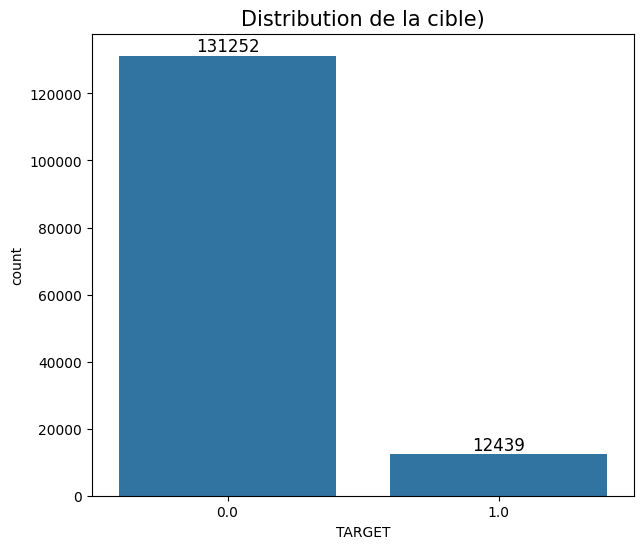

In [23]:
fig,ax=plt.subplots(figsize=(7,6))
plt.title("Distribution de la cible)", fontsize=15)
sns.countplot(x='TARGET', data=X_train)
for container in ax.containers:
    ax.bar_label(container,size=12,fmt='%.0f')
plt.show()

In [24]:
print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test_kag.shape)

Dimensions de X_train : (143691, 37)
Dimensions de X_test : (15588, 38)


In [25]:
X_train['TARGET'].value_counts(dropna=False)

TARGET
0.0    131252
1.0     12439
Name: count, dtype: int64

In [26]:
# Vérifier les valeurs manquantes dans X_train
missing_values = X_train.isna().sum()

# Afficher les valeurs manquantes par colonne
print("Valeurs manquantes dans X_train :")
print(missing_values.sum())

Valeurs manquantes dans X_train :
0


In [27]:
# Calculer le pourcentage de valeurs manquantes par colonne
missing_percentages = X_train.isna().mean() * 100

# Créer un DataFrame pour afficher les résultats
missing_table = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing Percentage': missing_percentages.values
}).sort_values(by='Missing Percentage', ascending=False)

# Ajouter une ligne pour le total
total_missing_percentage = missing_percentages.mean()
missing_table = pd.concat([missing_table, pd.DataFrame({
    'Feature': ['Total'],
    'Missing Percentage': [total_missing_percentage]
})], ignore_index=True)

# Afficher le tableau
pd.set_option('display.max_rows', None)
print("Pourcentage de valeurs manquantes par feature :")
print(missing_table)

Pourcentage de valeurs manquantes par feature :
                                   Feature  Missing Percentage
0                             EXT_SOURCE_2                 0.0
1      NAME_EDUCATION_TYPE_Highereducation                 0.0
2                APPROVED_CNT_PAYMENT_MEAN                 0.0
3                     BURO_DAYS_CREDIT_MAX                 0.0
4                   INSTAL_AMT_PAYMENT_MIN                 0.0
5            INSTAL_DAYS_ENTRY_PAYMENT_SUM                 0.0
6                  POS_MONTHS_BALANCE_SIZE                 0.0
7   PREV_NAME_CONTRACT_STATUS_Refused_MEAN                 0.0
8                        DAYS_REGISTRATION                 0.0
9                 PREV_APP_CREDIT_PERC_MIN                 0.0
10              APPROVED_DAYS_DECISION_MIN                 0.0
11                 INSTAL_AMT_PAYMENT_MEAN                 0.0
12                          INSTAL_DBD_SUM                 0.0
13               INSTAL_AMT_INSTALMENT_MAX                 0.0
14     

In [28]:
def missing_values_count(df):
    # Calculer le pourcentage de valeurs manquantes par colonne
    missing_percentages = df.isna().mean() * 100
    
    # Créer des bins pour les pourcentages de valeurs manquantes
    bins = [0, 0.01, 20, 40, 60, 100]  # 0%, 0-20%, 20-40%, 40-60%, 60-100%
    labels = ['0%', '0-20%', '20-40%', '40-60%', '60-100%']
    
    # Classer les caractéristiques dans les bins
    missing_bins = pd.cut(missing_percentages, bins=bins, labels=labels, right=False)
    
    # Compter le nombre de variables par bin
    bin_counts = missing_bins.value_counts().sort_index()
    
    # Calculer le pourcentage de variables dans chaque bin par rapport au total
    total_variables = len(missing_percentages)
    bin_percentages = (bin_counts / total_variables) * 100
    
    # Créer un DataFrame pour afficher les résultats
    bin_summary = pd.DataFrame({
        'Number of Variables': bin_counts,
        'Percentage of Total': bin_percentages
    })
    
    # Afficher le nombre de variables par bin et leur pourcentage par rapport au total
    print("Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :")
    print(bin_summary)

In [29]:
missing_values_count(X_train)

Nombre de variables par bin de valeurs manquantes et leur pourcentage par rapport au total :
         Number of Variables  Percentage of Total
0%                        37                100.0
0-20%                      0                  0.0
20-40%                     0                  0.0
40-60%                     0                  0.0
60-100%                    0                  0.0


# Modélisations + MLflow

## Split données

In [30]:
# Séparer les caractéristiques et la cible
X = X_train.drop(columns=['TARGET'])
y = X_train['TARGET']

# Remplacer les valeurs infinies par NaN ___ "XGBoostError : Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`"
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer les NaN par la moyenne de la colonne
#X.fillna(X.mean(), inplace=True)

In [31]:
X.columns

Index(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'PAYMENT_RATE', 'INSTAL_DPD_MEAN',
       'INSTAL_AMT_PAYMENT_SUM', 'AMT_ANNUITY', 'DAYS_BIRTH', 'CODE_GENDER',
       'ANNUITY_INCOME_PERC', 'APPROVED_AMT_DOWN_PAYMENT_MAX',
       'DAYS_EMPLOYED_PERC', 'BURO_DAYS_CREDIT_MEAN', 'PREV_CNT_PAYMENT_MEAN',
       'AMT_GOODS_PRICE', 'BURO_AMT_CREDIT_SUM_DEBT_MEAN',
       'ACTIVE_DAYS_CREDIT_MAX', 'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN',
       'PREV_APP_CREDIT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_MEAN',
       'NAME_EDUCATION_TYPE_Highereducation', 'DAYS_ID_PUBLISH',
       'APPROVED_CNT_PAYMENT_MEAN', 'BURO_DAYS_CREDIT_MAX',
       'INSTAL_AMT_PAYMENT_MIN', 'INSTAL_DAYS_ENTRY_PAYMENT_SUM',
       'POS_MONTHS_BALANCE_SIZE', 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
       'DAYS_REGISTRATION', 'PREV_APP_CREDIT_PERC_MIN',
       'APPROVED_DAYS_DECISION_MIN', 'INSTAL_AMT_PAYMENT_MEAN',
       'INSTAL_DBD_SUM', 'INSTAL_AMT_INSTALMENT_MAX', 'INCOME_CREDIT_PERC',
       'INSTAL_DAYS_ENTRY_PAYMENT_MEAN', 'INSTAL_PAYM

In [32]:
X.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,PREV_NAME_CONTRACT_STATUS_Refused_MEAN,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN
0,0.262949,0.139376,0.060749,0.000000,219625.68750,24700.5,-9461,0,0.121978,0.0,...,0.0,-3648.0,1.000000,-606.0,11559.247070,388.0,53093.746094,0.498036,-315.421051,0.000000
5,0.354225,0.621226,0.056101,37.628571,957617.62500,27517.5,-16941,0,0.277955,12145.5,...,0.0,-4970.0,0.896459,-2536.0,27360.501953,403.0,432218.281250,0.201837,-1237.800049,342.461578
6,0.724000,0.492060,0.026463,0.137255,487995.12500,41301.0,-13778,1,0.241526,22032.0,...,0.0,-1213.0,1.000000,-1562.0,9568.532227,445.0,17341.605469,0.109564,-864.411743,0.000000
7,0.714279,0.540654,0.027500,0.000000,274492.09375,42075.0,-18850,0,0.116875,0.0,...,0.0,-4597.0,0.947859,-1070.0,27449.207031,119.0,27463.410156,0.235294,-915.900024,0.000000
10,0.651862,0.363945,0.032455,1.052632,166880.75000,21177.0,-10197,1,0.188240,0.0,...,0.0,-4427.0,0.904484,-844.0,8783.197266,176.0,14045.625000,0.172414,-584.473694,3043.009033


In [33]:
y.head()

0     1.0
5     0.0
6     0.0
7     0.0
10    0.0
Name: TARGET, dtype: float32

In [34]:
# Diviser les données en ensembles d'entraînement et de test 
# => passé dans le modèle pour intégration smote

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

## training + MLflow

L'intégration d'un "F-beta score personnalisé" a été conseillé en mentorat pour prendre en compte le déséquilibre des coûts entre les faux négatifs (FN) et les faux positifs (FP). Le F-beta score est une généralisation du F1-score qui permet de donner plus de poids à la précision ou au rappel selon le besoin.

Le F-beta score personnalisé est défini par la formule suivante :
$$
F_\beta = (1 + \beta^2) \cdot \frac{\text{précision} \cdot \text{rappel}}{(\beta^2 \cdot \text{précision}) + \text{rappel}}
$$
Où :
- $\beta$ est un paramètre qui contrôle l'importance relative de la précision par rapport au rappel.
- $\text{précision}$ est la précision du modèle.
- $\text{rappel}$ est le rappel du modèle.

Spécificités de la problématique actuelle :

On souhaite minimiser les faux négatifs (FN) car ils sont plus coûteux que les faux positifs (FP). On peut donc choisir un β>1 pour donner plus de poids au rappel.



Autres fonctionnalités :

- tracking MLflow
- hyperparamètres avec gridsearchcv
- recherche sur plusieurs modèles
- possibilités de faire un SMOTE ou d'utiliser des poids de classe
   - dans le cas d'un SMOTE, on garde les X_test & y_test d'origine en utilisant de nouveaux X_train / y_train

In [36]:
# Fonction pour optimiser le seuil en fonction du F-beta score
def optimize_threshold(y_true, y_proba, beta=3):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    fbeta_scores = []
    for precision, recall in zip(precisions, recalls):
        fbeta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
        fbeta_scores.append(fbeta)
    optimal_threshold = thresholds[np.argmax(fbeta_scores)]
    return optimal_threshold

In [37]:
# Fonction pour effectuer une recherche d'hyperparamètres et enregistrer les résultats
def grid_search_and_log_model(model, model_name, param_grid, file_name, use_smote=False, class_weights=None):
    print(f"Entraînement du modèle : {model_name}")
    with mlflow.start_run():
        # Ajouter un tag pour identifier le type de modèle et le fichier initial
        mlflow.set_tag("model_type", model_name)
        mlflow.set_tag("file_name", file_name)

        # Diviser les données en ensembles d'entraînement et de test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # Rééchantillonnage avec SMOTE
        if use_smote:
            smote = SMOTE(random_state=42)
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        else:
            X_train_resampled, y_train_resampled = X_train, y_train

        # Appliquer les poids de classe si spécifiés
        if class_weights is not None:
            if model_name == "XGBoost":
                # Ajouter un range de valeurs pour scale_pos_weight
                param_grid["scale_pos_weight"] = [1, class_weights / 2, class_weights]
            elif model_name in ["LightGBM", "ExtraTrees"]:
                # Ajouter un range de valeurs pour class_weight
                param_grid["class_weight"] = [None, {0: 1, 1: class_weights / 2}, {0: 1, 1: class_weights}]

        # Effectuer une recherche d'hyperparamètres
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')
        grid_search.fit(X_train_resampled, y_train_resampled)

        # Imprimer les paramètres spécifiques pour chaque run
        for i, params in enumerate(grid_search.cv_results_['params']):
            print(f"Run {i + 1} pour {model_name} avec les paramètres : {params}")

        # Prédire et calculer les métriques
        best_model = grid_search.best_estimator_
        y_proba = best_model.predict_proba(X_test)[:, 1]
        optimal_threshold = optimize_threshold(y_test, y_proba, beta=3)
        predictions = (y_proba >= optimal_threshold).astype(int)

        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, average='weighted')
        recall = recall_score(y_test, predictions, average='weighted')
        f1 = f1_score(y_test, predictions, average='weighted')
        f2 = fbeta_score(y_test, predictions, average='weighted', beta=2)

        # Imprimer les métriques de manière compacte
        print(f"Modèle : {model_name} | Meilleurs paramètres : {grid_search.best_params_} \n| "
              f"Accuracy : {accuracy:.4f} | Precision : {precision:.4f} | Recall : {recall:.4f} | F1 Score : {f1:.4f} | F2 Score : {f2:.4f} | Seuil Optimal : {optimal_threshold:.4f}")

        # Enregistrer les paramètres et les métriques
        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("f2_score", f2)
        mlflow.log_metric("optimal_threshold", optimal_threshold)

        # Enregistrer le modèle avec un exemple d'entrée
        input_example = X_train[:1]  # Utiliser un exemple d'entrée
        mlflow.sklearn.log_model(best_model, "model", input_example=input_example)

        return best_model, accuracy, precision, f2, optimal_threshold

In [38]:
# Définir les modèles et les espaces de recherche des hyperparamètres
models = {
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    },
    "LightGBM": {
        "model": LGBMClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "num_leaves": [20, 30, 40, 50]
    }
    },
    "ExtraTrees": {
        "model": ExtraTreesClassifier(),
        "param_dist": {
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5, 10]
        }
    }
}

In [39]:
file_name = X_train_filename
file_name

'train_df_cleaned.parquet.gzip'

In [40]:
# Exporter un exemple d'entrée pour tests requête API
input_example = X_train[:1]
input_example_df = pd.DataFrame(input_example, columns=X_train.columns)
input_example_df.to_csv(csv_path_output + 'input_example.csv', index=False)

In [41]:
# Effectuer une recherche d'hyperparamètres et enregistrer les résultats pour chaque modèle
best_models = []
best_xgb = None
best_lgbm = None
best_XRF = None

for model_name, config in models.items():
    best_model, accuracy, precision, f2, optimal_threshold = grid_search_and_log_model(
        config["model"], model_name, config["param_dist"], file_name, use_smote=True, class_weights=None
    )
    best_models.append((best_model, accuracy, precision, f2, optimal_threshold, model_name))

    current_datetime = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    # Exporter le meilleur modèle avec Pickle
    model_filename = f"{models_dir}/best_model_{model_name.lower()}_{current_datetime}_precision_{precision:.4f}_accuracy_{accuracy:.4f}_f2_{f2:.4f}_opt_threshold_{optimal_threshold:.4f}.pkl"
    with open(model_filename, 'wb') as file:
        pickle.dump(best_model, file)

    print(f"Le meilleur modèle {model_name} a été exporté dans '{model_filename}'")

    # Enregistrer le nom du meilleur modèle pour chaque type
    if model_name == "XGBoost":
        best_xgb = model_filename
    elif model_name == "LightGBM":
        best_lgbm = model_filename
    elif model_name == "ExtraTrees":
        best_XRF = model_filename

Entraînement du modèle : XGBoost
Run 1 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Run 2 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Run 3 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Run 4 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
Run 5 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Run 6 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Run 7 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100}
Run 8 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Run 9 pour XGBoost avec les paramètres : {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300}
Run 10 pour XGBoost avec les paramètres : {'learn

In [42]:
# Trouver le modèle avec la meilleure précision
best_model_info = max(best_models, key=lambda x: x[1])
best_model, best_accuracy, best_precision, best_f2, best_optimal_threshold, best_model_name = best_model_info
print(f"Le meilleur modèle est {best_model_name} avec une accuracy de {best_accuracy:.4f}, une précision de {best_precision:.4f} et un seuil optimal de {best_optimal_threshold:.4f}")

Le meilleur modèle est LightGBM avec une accuracy de 0.9130, une précision de 0.8337 et un seuil optimal de 0.9795


In [43]:
# Afficher les noms des meilleurs modèles pour chaque type
print(f"Meilleur modèle XGBoost : {best_xgb}")
print(f"Meilleur modèle LightGBM : {best_lgbm}")
print(f"Meilleur modèle ExtraTrees : {best_XRF}")

Meilleur modèle XGBoost : ../models/best_model_xgboost_2025-05-28_21-19-53_precision_0.8337_accuracy_0.9130_f2_0.8960_opt_threshold_0.9804.pkl
Meilleur modèle LightGBM : ../models/best_model_lightgbm_2025-05-28_21-29-04_precision_0.8337_accuracy_0.9130_f2_0.8960_opt_threshold_0.9795.pkl
Meilleur modèle ExtraTrees : ../models/best_model_extratrees_2025-05-28_21-38-30_precision_0.8337_accuracy_0.9130_f2_0.8960_opt_threshold_0.7894.pkl


In [44]:
# Trouver le modèle avec la meilleure précision
best_model_info = max(best_models, key=lambda x: x[1])
best_model, best_accuracy, best_precision, best_f2, best_optimal_threshold, best_model_name = best_model_info
print(f"Le meilleur modèle est {best_model_name} avec une accuracy de {best_accuracy:.4f}, une précision de {best_precision:.4f} et un seuil optimal de {best_optimal_threshold:.4f}")

Le meilleur modèle est LightGBM avec une accuracy de 0.9130, une précision de 0.8337 et un seuil optimal de 0.9795


# Export modèle .pkl > API

In [45]:
best_lgbm

'../models/best_model_lightgbm_2025-05-28_21-29-04_precision_0.8337_accuracy_0.9130_f2_0.8960_opt_threshold_0.9795.pkl'

In [46]:
# Chemin du dossier de destination
destination_dir = '../app_oc_p7/app_API/app'
os.makedirs(destination_dir, exist_ok=True)

#source_file = models_dir + best_lgbm

In [47]:
# Chemin complet du fichier de destination avec le nouveau nom
destination_file = os.path.join(destination_dir, 'model.pkl')

# Copier le fichier dans le dossier de destination et le renommer
shutil.copy(best_lgbm, destination_file)

print(f"Le fichier {best_lgbm} a été copié et renommé en {destination_file}")

Le fichier ../models/best_model_lightgbm_2025-05-28_21-29-04_precision_0.8337_accuracy_0.9130_f2_0.8960_opt_threshold_0.9795.pkl a été copié et renommé en ../app_oc_p7/app_API/app/model.pkl


In [48]:
import re

In [49]:
# Utiliser une expression régulière pour extraire le seuil optimal
match = re.search(r'opt_threshold_([\d.]+?)(?=\.pkl|$)', best_lgbm)
if match:
    optimal_threshold = float(match.group(1))
    print(f"Optimal Threshold: {optimal_threshold}")
else:
    print("Optimal threshold not found in the filename.")

Optimal Threshold: 0.9795


In [50]:
optimal_threshold

0.9795

In [51]:
# Chemin vers le fichier config.py
#config_file_path = '../app_API/app/config.py'
config_file_path = destination_dir + '/config.py'

# Écrire la valeur de optimal_threshold dans config.py
with open(config_file_path, 'w') as config_file:
    config_file.write(f"optimal_threshold = {optimal_threshold}\n")

print(f"Optimal threshold {optimal_threshold} has been written to {config_file_path}.")

Optimal threshold 0.9795 has been written to ../app_oc_p7/app_API/app/config.py.


In [53]:
# Sauvegarder la variable best_lgbm dans un fichier texte en écrasant le contenu existant
#best_lgbm_write = best_lgbm.replace('../models/', '')

#with open('../app_API/app/best_lgbm.txt', 'w') as file:
#    file.write(best_lgbm_write)

In [54]:
# Test lecture
with open(config_file_path, 'r') as config_file:
    content = config_file.read()
print("Contenu de config.py :")
print(content)

Contenu de config.py :
optimal_threshold = 0.9795

